# 05 — The habitable zone, done on insolation (2026 rebuild)

**Question this notebook answers:** which Kepler planets and candidates receive an amount of starlight that would let an Earth-like world keep liquid water, and are small enough to plausibly be rocky?

**Inputs:** the raw snapshot (the screen needs the uncertainty columns). **Outputs:** `reports/tables/05_hz_confirmed.csv`, `05_hz_candidates.csv`, figures in `reports/figures/habitable_zone/`.

> **What changed since 2020** (details: *notes/Research Log/2026-08-24 Review 05_habitable_zone*)
> - 2020 filtered on orbital period and the *star* (temperature, radius, metallicity) and never looked at the planet: its 12 "habitable" planets were 3.3–11.7 Earth radii receiving 1.5–4.9× Earth's sunlight.
> - Here the screen is the standard one: **insolation** (`koi_insol`) between the stellar-temperature-dependent limits of **Kopparapu et al. 2014**, plus a **planet-radius ceiling** (Rogers 2015).
> - **All host stars are in scope** (decision 2026-08-24); "Sun-like host" is a flag, not a filter. The catalogue uncertainties on insolation are carried, not dropped.
> - The 2020 filter is reproduced at the end for comparison (it matches the 2020 pickles exactly) and scored against the new screen.
> - Caveat: dispositions and parameters are the Kaggle-era snapshot (DR25 parameters). Phase 3 re-runs this on the live archive table, where some of these rows have since changed class.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kepler import data, habitable, viz
from kepler.data import TARGET, label
from kepler.habitable import KOPPARAPU_2014, ROCKY_RADIUS, SUPER_EARTH_RADIUS, TEFF_VALID, seff_limit
from kepler.paths import FIGURES, REPORTS

viz.apply_style()
FIG_DIR = FIGURES / "habitable_zone"; FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = REPORTS / "tables"; TABLE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 180); pd.set_option("display.precision", 3)
LIMIT_LABELS = {"recent_venus": "recent Venus (optimistic inner)", "runaway_greenhouse": "runaway greenhouse (conservative inner)",
                "maximum_greenhouse": "maximum greenhouse (conservative outer)", "early_mars": "early Mars (optimistic outer)"}
LIMIT_COLORS = dict(zip(KOPPARAPU_2014, ["#d9a066", "#b86200", "#7a4100", "#3d2100"]))

## 1. The method

Kopparapu et al. (2014), Table 1, give each habitable-zone boundary as an effective stellar flux that depends on the host star's temperature:

$S_\mathrm{eff} = S_{\mathrm{eff},\odot} + a\,T + b\,T^2 + c\,T^3 + d\,T^4,\qquad T = T_\mathrm{eff} - 5780\ \mathrm{K}$

valid for 2,600–7,200 K. A planet is in the zone when its insolation (`koi_insol`, Earth = 1) lies between the inner and outer limits. *Conservative* = runaway greenhouse to maximum greenhouse; *optimistic* = recent Venus to early Mars. For a Sun-like star that is 1.107 → 0.356 (conservative) and 1.776 → 0.320 (optimistic) Earth flux.

Radius: Rogers (2015) finds that most planets larger than about 1.6 Earth radii are too low-density to be rocky, so **≤ 1.6 R⊕ = plausibly rocky**, with **≤ 2.0 R⊕** as the looser super-Earth cut.

In [2]:
coef = pd.DataFrame(KOPPARAPU_2014, index=["S_eff_sun", "a", "b", "c", "d"]).T
coef.index = [LIMIT_LABELS[i] for i in coef.index]
print("sanity check at 5780 K (must equal S_eff_sun):", {k: float(seff_limit(5780, k)) for k in KOPPARAPU_2014})
coef.style.format({"S_eff_sun": "{:.3f}", "a": "{:.3e}", "b": "{:.3e}", "c": "{:.3e}", "d": "{:.3e}"}).set_caption("Kopparapu et al. 2014, Table 1, 1 Earth-mass planet")

sanity check at 5780 K (must equal S_eff_sun): {'recent_venus': 1.776, 'runaway_greenhouse': 1.107, 'maximum_greenhouse': 0.356, 'early_mars': 0.32}


,S_eff_sun,a,b,c,d
recent Venus (optimistic inner),1.776,2.136e-04,2.533e-08,-1.332e-11,-3.097e-15
runaway greenhouse (conservative inner),1.107,1.332e-04,1.580e-08,-8.308e-12,-1.931e-15
maximum greenhouse (conservative outer),0.356,6.171e-05,1.698e-09,-3.198e-12,-5.575e-16
early Mars (optimistic outer),0.320,5.547e-05,1.526e-09,-2.874e-12,-5.011e-16


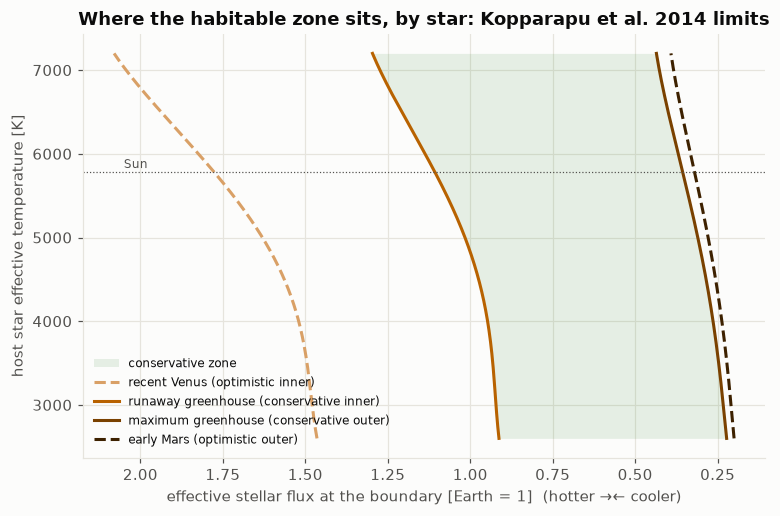

In [3]:
teff_grid = np.linspace(*TEFF_VALID, 300)
fig, ax = viz.new_figure(8, 5)
inner_c, outer_c = seff_limit(teff_grid, "runaway_greenhouse"), seff_limit(teff_grid, "maximum_greenhouse")
ax.fill_betweenx(teff_grid, outer_c, inner_c, color=viz.CLASS_COLORS["CONFIRMED"], alpha=0.10, lw=0, label="conservative zone")
for limit in KOPPARAPU_2014:
    ax.plot(seff_limit(teff_grid, limit), teff_grid, color=LIMIT_COLORS[limit], lw=2,
            ls="-" if limit in habitable.CONSERVATIVE else "--", label=LIMIT_LABELS[limit])
ax.axhline(5780, color=viz.TEXT_SECONDARY, lw=0.8, ls=":"); ax.text(2.05, 5830, "Sun", fontsize=8, color=viz.TEXT_SECONDARY)
ax.invert_xaxis()
ax.set_xlabel("effective stellar flux at the boundary [Earth = 1]  (hotter →← cooler)")
ax.set_ylabel("host star effective temperature [K]")
ax.set_title("Where the habitable zone sits, by star: Kopparapu et al. 2014 limits")
ax.legend(loc="lower left", fontsize=8)
fig.savefig(FIG_DIR / "hz_limits_vs_teff.png")
plt.show()

> Cooler stars have their zone at lower flux (their light is redder, which an Earth-like atmosphere absorbs more efficiently), so a fixed "0.35–1.0 Earth flux" band would misplace planets around M and K dwarfs. The 2020 period window of 200–400 days, by contrast, corresponds to orbits *inside* the inner edge for the Sun-like stars it selected.

## 2. Apply the screen to every KOI

The flags are computed for all 9,564 rows; hot stars above 7,200 K (242 KOIs) fall outside the model's validity and get no zone flags rather than an extrapolation.

In [4]:
raw = data.load_kaggle_snapshot()
hz = habitable.hz_table(raw)
print("KOIs with a stellar temperature:", int(hz["koi_steff"].notna().sum()), "| inside the model's 2,600–7,200 K range:", int(hz["teff_in_range"].sum()),
      "| above 7,200 K:", int((hz["koi_steff"] > 7200).sum()))
display(habitable.summarise(hz, "CONFIRMED").style.set_caption("CONFIRMED planets inside each zone"))
display(habitable.summarise(hz, "CANDIDATE").style.set_caption("CANDIDATE objects inside each zone"))

KOIs with a stellar temperature: 9201 | inside the model's 2,600–7,200 K range: 8959 | above 7,200 K: 242


,any radius,radius <= 2.0,radius <= 1.6,"radius <= 2.0, Sun-like host","radius <= 2.0, cooler host"
hz_conservative,31,15,8,1,14
hz_optimistic,57,23,11,2,21


,any radius,radius <= 2.0,radius <= 1.6,"radius <= 2.0, Sun-like host","radius <= 2.0, cooler host"
hz_conservative,117,49,27,36,13
hz_optimistic,173,62,34,45,17


## 3. Confirmed planets in the conservative zone, small enough to be rocky-ish

Sorted from the outer edge inward. `possible` means the planet stays inside the zone somewhere within its catalogue insolation uncertainty. The pipeline verdict column is the "other Y": two of these are archive-CONFIRMED but were flagged by the DR25 pipeline.

In [5]:
COLS = ["kepler_name", "koi_period", "koi_prad", "koi_insol", "koi_insol_err1", "koi_insol_err2", "koi_steff",
        "sunlike_host", "rocky", "hz_conservative_possible", "koi_pdisposition"]
confirmed_small = hz[(hz[TARGET] == "CONFIRMED") & hz["hz_conservative"] & hz["super_earth"]].sort_values("koi_insol")
confirmed_small[COLS].rename(columns={"hz_conservative_possible": "possible", "koi_pdisposition": "pipeline verdict"})

,kepler_name,koi_period,koi_prad,koi_insol,koi_insol_err1,koi_insol_err2,koi_steff,sunlike_host,rocky,possible,pipeline verdict
kepoi_name,,,,,,,,,,,
K04356.01,Kepler-1593 b,174.510,1.74,0.28,0.09,-0.09,4367.0,False,False,True,CANDIDATE
K04622.01,Kepler-441 b,207.248,1.56,0.30,0.06,-0.05,4339.0,False,True,True,CANDIDATE
K02418.01,Kepler-1229 b,86.830,1.68,0.35,0.08,-0.11,3576.0,False,False,True,CANDIDATE
K01422.04,Kepler-296 f,63.335,1.18,0.39,0.15,-0.13,3526.0,False,True,True,CANDIDATE
K01596.02,Kepler-309 c,105.358,1.87,0.41,0.09,-0.10,3883.0,False,False,True,CANDIDATE
K00701.04,Kepler-62 f,267.283,1.43,0.44,0.09,-0.07,4926.0,False,True,True,FALSE POSITIVE
K03138.01,Kepler-1649 b,8.689,0.49,0.47,0.00,0.00,2703.0,False,True,True,CANDIDATE
K07016.01,Kepler-452 b,384.848,1.09,0.56,0.32,-0.15,5579.0,True,True,True,CANDIDATE
K04087.01,Kepler-440 b,101.111,1.61,0.65,0.14,-0.11,4133.0,False,False,True,CANDIDATE


In [6]:
possible = hz[(hz[TARGET] == "CONFIRMED") & hz["hz_conservative_possible"] & hz["super_earth"]]
print(f"strictly inside: {len(confirmed_small)} | inside within the insolation uncertainty: {len(possible)}")
print("added by the uncertainty:", sorted(set(possible["kepler_name"]) - set(confirmed_small["kepler_name"])))

strictly inside: 15 | inside within the insolation uncertainty: 18
added by the uncertainty: ['Kepler-1512 b', 'Kepler-186 f', 'Kepler-560 b']


### The habitable-zone diagram

Every confirmed planet, with the small (≤ 2 R⊕) conservative-zone planets labelled. Notice where they sit: almost all of them orbit stars cooler than the Sun, which is exactly the region the 2020 temperature window excluded.

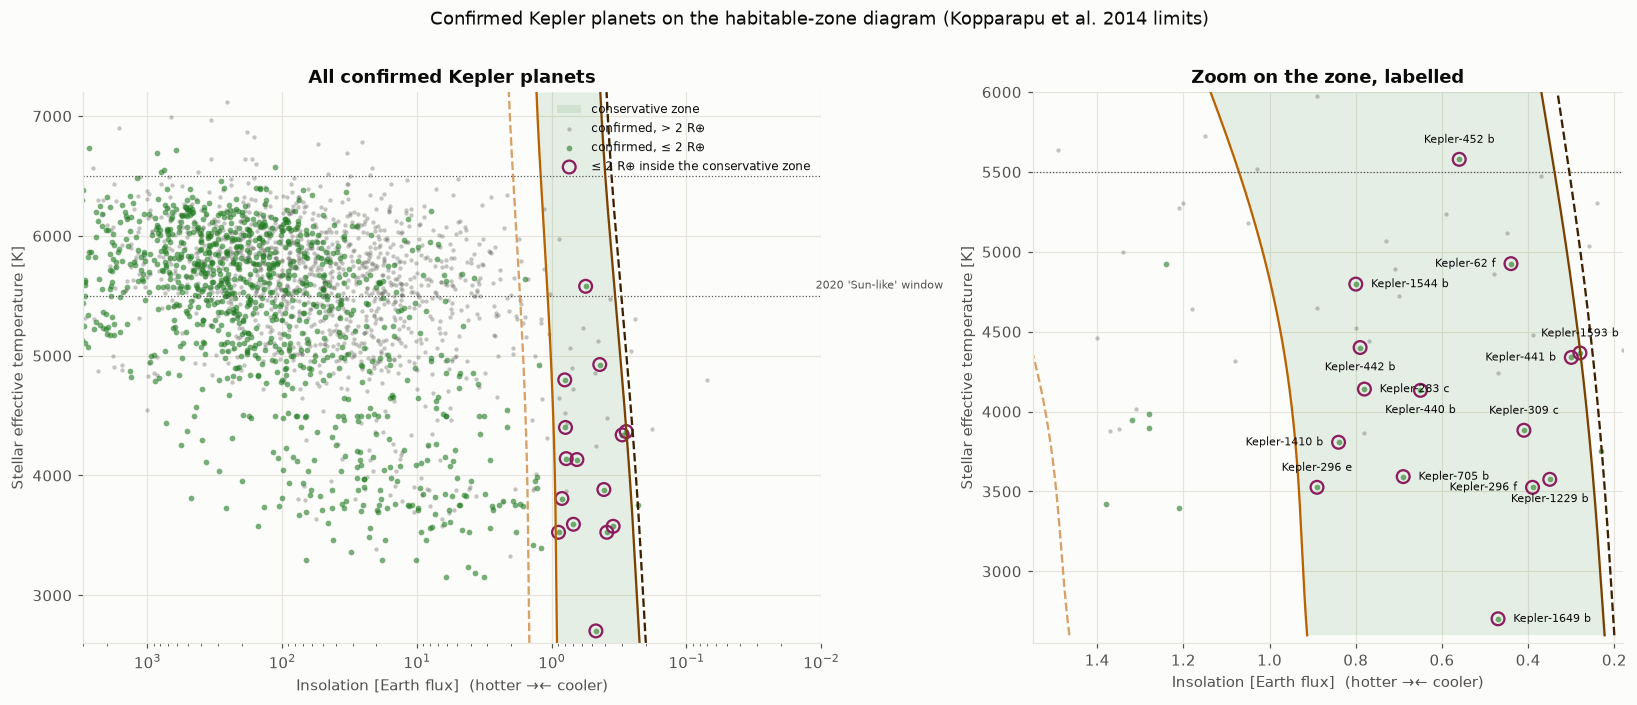

In [7]:
conf = hz[(hz[TARGET] == "CONFIRMED") & hz["teff_in_range"] & hz["koi_insol"].notna()]
big = conf[~conf["super_earth"]]; small = conf[conf["super_earth"]]; hit = confirmed_small

def draw(ax, zoom):
    ax.fill_betweenx(teff_grid, outer_c, inner_c, color=viz.CLASS_COLORS["CONFIRMED"], alpha=0.10, lw=0, label="conservative zone")
    for limit in KOPPARAPU_2014:
        ax.plot(seff_limit(teff_grid, limit), teff_grid, color=LIMIT_COLORS[limit], lw=1.5, ls="-" if limit in habitable.CONSERVATIVE else "--")
    ax.scatter(big["koi_insol"], big["koi_steff"], s=8, alpha=0.35, color=viz.NEUTRAL, marker="o", linewidths=0, label="confirmed, > 2 R⊕")
    ax.scatter(small["koi_insol"], small["koi_steff"], s=14, alpha=0.6, color=viz.CLASS_COLORS["CONFIRMED"], marker="o", linewidths=0, label="confirmed, ≤ 2 R⊕")
    ax.scatter(hit["koi_insol"], hit["koi_steff"], s=70, facecolor="none", edgecolor=viz.CLASS_COLORS["FALSE POSITIVE"], linewidths=1.5, label="≤ 2 R⊕ inside the conservative zone")
    ax.axhline(5500, color=viz.TEXT_SECONDARY, lw=0.8, ls=":"); ax.axhline(6500, color=viz.TEXT_SECONDARY, lw=0.8, ls=":")
    ax.set_ylabel(label("koi_steff"))
    if zoom:
        offsets = [(10, 0, "left", "center"), (-10, 0, "right", "center"), (0, 9, "center", "bottom"), (0, -9, "center", "top")]
        for i, (_, row) in enumerate(hit.sort_values(["koi_steff", "koi_insol"]).iterrows()):
            dx, dy, ha, va = offsets[i % 4]
            ax.annotate(row["kepler_name"], (row["koi_insol"], row["koi_steff"]), xytext=(dx, dy), textcoords="offset points",
                        fontsize=7.5, ha=ha, va=va)
        ax.set_xlim(1.55, 0.18); ax.set_ylim(2550, 6000)
        ax.set_title("Zoom on the zone, labelled")
    else:
        ax.set_xscale("log"); ax.set_xlim(3e3, 1e-2); ax.set_ylim(2600, 7200)
        ax.text(0.011, 5560, "2020 'Sun-like' window", fontsize=7.5, color=viz.TEXT_SECONDARY)
        ax.set_title("All confirmed Kepler planets")
        ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel(label("koi_insol") + "  (hotter →← cooler)")

fig, axes = plt.subplots(1, 2, figsize=(15, 6.3), gridspec_kw={"width_ratios": [1.25, 1]})
draw(axes[0], zoom=False); draw(axes[1], zoom=True)
fig.suptitle("Confirmed Kepler planets on the habitable-zone diagram (Kopparapu et al. 2014 limits)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "hz_diagram_confirmed.png")
plt.show()

## 4. Candidates worth a second look

CANDIDATE objects inside the conservative zone with radius ≤ 2 R⊕. Most orbit Sun-like stars with year-long periods and low transit signal-to-noise: the frontier of what Kepler could detect, and precisely where false alarms hide. The table keeps the signal-to-noise and the vetting score so the reader can judge; no further gate is applied here.

In [8]:
cand = hz[(hz[TARGET] == "CANDIDATE") & hz["hz_conservative"] & hz["super_earth"]].sort_values("koi_insol")
print(len(cand), "candidates | Sun-like host:", int(cand["sunlike_host"].sum()), "| radius ≤ 1.6:", int(cand["rocky"].sum()),
      "| signal-to-noise ≥ 10:", int((cand["koi_model_snr"] >= 10).sum()), "| with a vetting score:", int(cand["koi_score"].notna().sum()))
cand[["koi_period", "koi_prad", "koi_insol", "koi_steff", "koi_model_snr", "koi_score", "sunlike_host", "rocky"]]

49 candidates | Sun-like host: 36 | radius ≤ 1.6: 27 | signal-to-noise ≥ 10: 15 | with a vetting score: 22


,koi_period,koi_prad,koi_insol,koi_steff,koi_model_snr,koi_score,sunlike_host,rocky
kepoi_name,,,,,,,,
K07591.01,328.322,1.30,0.33,4906.0,8.2,NaN,False,True
K04902.01,409.386,1.78,0.35,4955.0,10.3,NaN,False,False
K05829.01,583.853,1.97,0.35,5591.0,5.4,NaN,True,False
K08012.01,34.574,0.42,0.37,3374.0,5.7,0.989,False,True
K07716.01,483.364,1.27,0.39,5700.0,8.3,0.230,True,True
K05545.01,541.045,1.08,0.43,5829.0,8.8,NaN,True,True
K07923.01,395.131,0.97,0.44,5060.0,14.4,0.750,False,True
K08047.01,302.350,1.98,0.44,4829.0,8.0,0.513,False,False
K05556.01,631.991,1.86,0.46,5594.0,7.2,NaN,True,False


## 5. The 2020 filter, reproduced and compared

The 2020 box (200 < period < 400 d, 5,500 < T_eff < 6,500 K, stellar radius ≤ 2 R☉, metallicity > 0) is re-run with a left join to the stellar file so the join losses are visible. It reproduces the 2020 pickles exactly: 12 confirmed, 37 candidates.

In [9]:
joined, stats = habitable.legacy_2020_box(raw)
box_c = joined[joined["legacy_box"] & (joined[TARGET] == "CONFIRMED")]
box_k = joined[joined["legacy_box"] & (joined[TARGET] == "CANDIDATE")]
print("join:", stats, "| 2020 box survivors: confirmed", len(box_c), "candidates", len(box_k))
compare = hz.loc[box_c.index, ["kepler_name", "koi_period", "koi_prad", "koi_insol", "koi_steff", "hz_conservative", "hz_optimistic", "super_earth"]]
print("of the 12: in the conservative zone", int(compare["hz_conservative"].sum()), "| optimistic", int(compare["hz_optimistic"].sum()),
      "| radius ≤ 2 R⊕", int(compare["super_earth"].sum()), "| overlap with the new list:", len(set(box_c.index) & set(confirmed_small.index)))
compare.sort_values("koi_insol")

join: {'kois': 9564, 'without stellar extra': 434} | 2020 box survivors: confirmed 12 candidates 37
of the 12: in the conservative zone 0 | optimistic 2 | radius ≤ 2 R⊕ 0 | overlap with the new list: 0


,kepler_name,koi_period,koi_prad,koi_insol,koi_steff,hz_conservative,hz_optimistic,super_earth
kepoi_name,,,,,,,,
K05581.01,Kepler-1634 b,374.878,4.27,1.49,5636.0,False,True,False
K00351.01,Kepler-90 h,331.597,10.89,1.76,5970.0,False,True,False
K02076.02,Kepler-1085 b,219.322,6.11,2.27,6063.0,False,False,False
K01439.01,Kepler-849 b,394.625,7.79,2.65,5910.0,False,False,False
K03946.01,Kepler-1533 b,308.544,3.28,2.81,6325.0,False,False,False
K00139.01,Kepler-111 c,224.779,7.67,2.92,5873.0,False,False,False
K03762.01,Kepler-1519 b,240.799,10.31,3.22,5758.0,False,False,False
K00351.02,Kepler-90 g,210.601,7.70,3.22,5970.0,False,False,False
K03681.01,Kepler-1514 b,217.832,11.17,3.29,6259.0,False,False,False


## 6. Save

In [10]:
out_c = confirmed_small[COLS + ["koi_impact", "koi_model_snr", "hz_optimistic"]].copy(); out_c.insert(0, "run_date", "2026-08-24")
out_k = cand[["koi_period", "koi_prad", "koi_insol", "koi_insol_err1", "koi_insol_err2", "koi_steff", "koi_impact", "koi_model_snr", "koi_score", "sunlike_host", "rocky", "hz_conservative_possible", "koi_pdisposition"]].copy(); out_k.insert(0, "run_date", "2026-08-24")
out_c.to_csv(TABLE_DIR / "05_hz_confirmed.csv"); out_k.to_csv(TABLE_DIR / "05_hz_candidates.csv")
print("wrote reports/tables/05_hz_confirmed.csv", out_c.shape, "and reports/tables/05_hz_candidates.csv", out_k.shape)

wrote reports/tables/05_hz_confirmed.csv (15, 15) and reports/tables/05_hz_candidates.csv (49, 14)


## Summary

- **15 confirmed planets** sit in the conservative habitable zone with radius ≤ 2 R⊕ (**8** at ≤ 1.6 R⊕); 18 when the insolation uncertainty is allowed for. **14 of the 15 orbit stars cooler than 5,500 K**; Kepler-452 b is the only Sun-like-host case.
- **49 candidates** pass the same screen, most of them long-period, low signal-to-noise objects around Sun-like stars: worth a second look, not a discovery.
- The 2020 list (12 planets) reproduces exactly and shares **no member** with the new one: 0 of its 12 are in the conservative zone and none is below 3 R⊕. The old criteria found Sun-like stars with Earth-like years, not habitable planets.
- Every number here is snapshot-era. Phase 3 re-runs the screen on the live archive table, where dispositions have moved since (for example K03138.02, a FALSE POSITIVE here, was later published as the Earth-sized habitable-zone planet Kepler-1649 c — to be confirmed against the live table).